In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C:\Users\Aditee\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Aditee\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [3]:
data = pd.DataFrame({'Coupon Rate':[0,1,3,5,7,9],'yeild_6.175':[16.57,30.08,57.10,84.12,111.15,138.17],
                     'yeild_6.675':[14.39,27.22,52.87,78.52,104.17,129.82],
                     "yeild_6.925":[13.42,25.92,50.93,75.93,100.94,125.94],
                     "yeild_7.175":[12.51,24.70,49.09,73.48,97.87,122.25],
                     "yeild_7.425":[11.66,23.56,47.36,71.15,94.94,118.74],
                     "yeild_7.675":[10.88,22.49,45.71,68.94,92.16,115.39],
                     "yeild_8.175":[9.47,20.54,42.69,64.84,86.99,109.14]})
data = data.set_index('Coupon Rate')
data

,yeild_6.175,yeild_6.675,yeild_6.925,yeild_7.175,yeild_7.425,yeild_7.675,yeild_8.175
Coupon Rate,,,,,,,
0,16.57,14.39,13.42,12.51,11.66,10.88,9.47
1,30.08,27.22,25.92,24.70,23.56,22.49,20.54
3,57.10,52.87,50.93,49.09,47.36,45.71,42.69
5,84.12,78.52,75.93,73.48,71.15,68.94,64.84
7,111.15,104.17,100.94,97.87,94.94,92.16,86.99
9,138.17,129.82,125.94,122.25,118.74,115.39,109.14


In [4]:
pd.set_option("display.expand_frame_repr", 0)

In [5]:
yeild = data.columns.str.split('yeild_',expand = True)
x =[]
for i in yeild:
    x.append(round(float(i[1])/100,5))
x

[0.06175, 0.06675, 0.06925, 0.07175, 0.07425, 0.07675, 0.08175]

In [78]:
#coupon_frequency will be 0.5 if semiannual coupon paid, 0.25 for quartery coupons
def duration_cal(n, coupon_freq, fv, coupon_rate, yeild):
    
    t = 0
    pv_total = 0
    cf_time = 0
    
    for i in range(int(n/coupon_freq)):
        t = t + coupon_freq
        pv = np.exp((-1)*float(yeild)*t)
        if t != float(n):
            cf = coupon_rate*fv*coupon_freq
            cf_pv = round(pv*cf, 3)
            cf_time = cf_time + cf_pv*t
            pv_total = pv_total + cf_pv
            #print(t,cf, pv,cf_pv)
        elif t == float(n) :
            cf = fv + coupon_rate*fv*coupon_freq
            cf_pv = round(pv*cf, 3)
            cf_time = cf_time + cf_pv*t
            pv_total = pv_total + cf_pv
            #print(t, cf,pv,cf_pv,cf_time,pv_total)
    #print(pv_total)
    duration = round(cf_time/pv_total, 3)        
    return duration, round(pv_total,3)


In [80]:
duration_cal(3, 0.5,100,0.1,0.12),duration_cal(3, 0.5,100,0.1,0.52)

((2.653, 94.213), (2.374, 34.314))

In [8]:
duration_cal(30,0.25,100,0,0.07175)[1]

11.619

In [249]:
maturity = 30
compunding = 0.25
fv = 100
df = pd.DataFrame()
df_price = pd.DataFrame()
for k in data.index:
    c_dur = []
    c_price = []
    for i in x:
        #print(k/100,i)
        c_dur.append(duration_cal(maturity,compunding,fv,k/100,i)[0])
        c_price.append(duration_cal(maturity,compunding,fv,k/100,i)[1])
    df = pd.concat([df,pd.Series(c_dur)],axis =1)
    df_price = pd.concat([df_price,pd.Series(c_price)],axis =1)
#c_dur
df = df.T
df_price = df_price.T

df.columns = data.columns
df_price.columns = data.columns

df = df.set_index(data.index)
df_price = df_price.set_index(data.index)

df #duration

,yeild_6.175,yeild_6.675,yeild_6.925,yeild_7.175,yeild_7.425,yeild_7.675,yeild_8.175
Coupon Rate,,,,,,,
0,30.000,30.000,30.000,30.000,30.000,30.000,30.000
1,21.073,20.453,20.137,19.811,19.488,19.157,18.486
3,16.101,15.502,15.204,14.906,14.613,14.322,13.747
5,14.360,13.824,13.559,13.299,13.040,12.785,12.288
7,13.472,12.979,12.737,12.499,12.262,12.031,11.579
9,12.934,12.470,12.244,12.020,11.800,11.583,11.161


In [10]:
x

[0.06175, 0.06675, 0.06925, 0.07175, 0.07425, 0.07675, 0.08175]

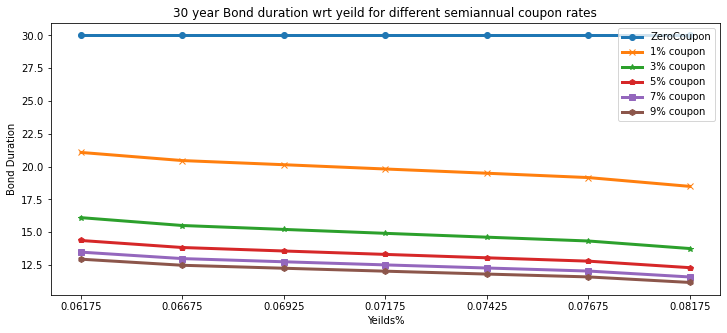

In [11]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(df.columns.to_numpy(),df.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
ax.plot(df.columns.to_numpy(),df.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
ax.plot(df.columns.to_numpy(),df.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
ax.plot(df.columns.to_numpy(),df.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
ax.plot(df.columns.to_numpy(),df.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
ax.plot(df.columns.to_numpy(),df.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")
ax.set_title("30 year Bond duration wrt yeild for different semiannual coupon rates")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Bond Duration")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()


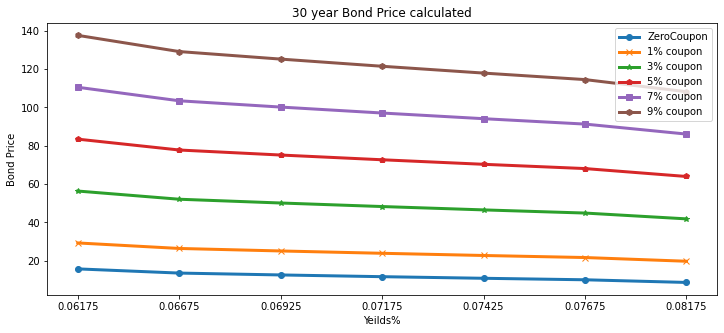

In [132]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(df_price.columns.to_numpy(),df_price.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
ax.plot(df_price.columns.to_numpy(),df_price.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
ax.plot(df_price.columns.to_numpy(),df_price.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
ax.plot(df_price.columns.to_numpy(),df_price.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
ax.plot(df_price.columns.to_numpy(),df_price.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
ax.plot(df_price.columns.to_numpy(),df_price.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")
ax.set_title("30 year Bond Price calculated")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Bond Price")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()

In [13]:
#for yeild at 7.175 and price is GIVEN (MARKET PRICE) and bond duration for x coupon is y. then predicted prices ?
##delta_p = (-1)*p*duration*delta_yeild
df_TD =pd.DataFrame()
df_diff = pd.DataFrame()
for r,i in enumerate(data.index):
    new_p = []
    temp_list = []
    for ind,k in enumerate(x):
        
        delta_p = (-1)*(data['yeild_7.175'][i])*(df['yeild_7.175'][i])*round(x[ind]-x[3],3)
        new_p.append(round(delta_p+data['yeild_7.175'][i],3))
        
        temp = str(round(delta_p+data['yeild_7.175'][i],3))+"("+str(round(round(delta_p+data['yeild_7.175'][i],3)-data.iloc[r,ind],3))+")"
        temp_list.append(temp)
    
    df_TD = pd.concat([df_TD,pd.Series(new_p)], axis =1)
    df_diff = pd.concat([df_diff,pd.Series(temp_list)], axis =1)
df_TD = df_TD.T
df_diff = df_diff.T
df_TD.columns = data.columns
df_diff.columns = data.columns
df_TD = df_TD.set_index(data.index)
df_diff = df_diff.set_index(data.index)
data,df_diff #differenece is related to Given Market Prices
#data.iloc[:,1],df_TD.iloc[:,1],data.iloc[:,1]-df_TD.iloc[:,1]

(             yeild_6.175  yeild_6.675  yeild_6.925  yeild_7.175  yeild_7.425  yeild_7.675  yeild_8.175
 Coupon Rate                                                                                           
 0                  16.57        14.39        13.42        12.51        11.66        10.88         9.47
 1                  30.08        27.22        25.92        24.70        23.56        22.49        20.54
 3                  57.10        52.87        50.93        49.09        47.36        45.71        42.69
 5                  84.12        78.52        75.93        73.48        71.15        68.94        64.84
 7                 111.15       104.17       100.94        97.87        94.94        92.16        86.99
 9                 138.17       129.82       125.94       122.25       118.74       115.39       109.14,
                  yeild_6.175      yeild_6.675      yeild_6.925  yeild_7.175      yeild_7.425      yeild_7.675      yeild_8.175
 Coupon Rate                           

In [127]:
#for yeild at 7.175 and price is CALCULATED usinf CASH FLOW and bond duration for x coupon is y. then predicted prices ?
##delta_p = (-1)*p*duration*delta_yeild
df_TD =pd.DataFrame()
df_diff = pd.DataFrame()
for r,i in enumerate(df_price.index):
    new_p = []
    temp_list = []
    for ind,k in enumerate(x):
        #print(round(x[ind]-x[3],3))
        delta_p = (-1)*(df_price['yeild_7.175'][i])*(df['yeild_7.175'][i])*round(x[ind]-x[3],4)
        new_p.append(round(delta_p+df_price['yeild_7.175'][i],3))
        #print(r, ind, data.iloc[r,ind])
        temp = str(round(delta_p+df_price['yeild_7.175'][i],3))+"("+str(round(round(delta_p+df_price['yeild_7.175'][i],3)-data.iloc[r,ind],3))+")"
        temp_list.append(temp)
        #print(delta_p)
    df_TD = pd.concat([df_TD,pd.Series(new_p)], axis =1)
    df_diff = pd.concat([df_diff,pd.Series(temp_list)], axis =1)
df_TD = df_TD.T
df_diff = df_diff.T
df_TD.columns = data.columns
df_diff.columns = data.columns
df_TD = df_TD.set_index(data.index)
df_diff = df_diff.set_index(data.index)
df_price,df_diff,df_TD
#data.iloc[:,1],df_TD.iloc[:,1],data.iloc[:,1]-df_TD.iloc[:,1]

(             yeild_6.175  yeild_6.675  yeild_6.925  yeild_7.175  yeild_7.425  yeild_7.675  yeild_8.175
 Coupon Rate                                                                                           
 0                 15.684       13.500       12.524       11.619       10.780       10.001        8.608
 1                 29.232       26.355       25.047       23.832       22.686       21.615       19.675
 3                 56.332       52.058       50.091       48.242       46.492       44.841       41.802
 5                 83.434       77.761       75.139       72.664       70.298       68.072       63.935
 7                110.523      103.461      100.183       97.075       94.114       91.296       86.074
 9                137.627      129.163      125.230      121.487      117.927      114.529      108.198,
                  yeild_6.175      yeild_6.675      yeild_6.925      yeild_7.175      yeild_7.425      yeild_7.675      yeild_8.175
 Coupon Rate                       

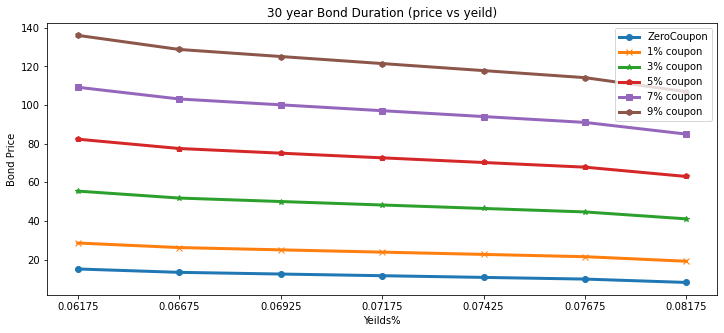

In [131]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")
ax.set_title("30 year Bond Duration (new price vs yeild)")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Bond Price")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()

# Modified Duration

In [88]:
m=2
k= []
maturity = 30
compunding =0.25
fv =100

for i in x:
    k.append(round(m*(np.exp(i/m)-1),4))
    #print(k,i)
    
#Modified Duration - for zero coupun bonds, the cf at maturity is 
dur_df = pd.DataFrame()
price_df = pd.DataFrame()
for i in data.index:
    c_dur = []
    c_price = []
    for r, t in enumerate(x):
        #print(k[r])
        c_dur.append((duration_cal(maturity,compunding,fv,i/100,t)[0])/(1+k[r]/m))
        #c_price.append(duration_cal(maturity,compunding,fv,i/100,t)[1])
    dur_df = pd.concat([dur_df,pd.DataFrame(c_dur)],axis = 1)
    #price_df = pd.concat([price_df,pd.DataFrame(c_price)],axis =1)
dur_df =dur_df.T
#price_df = price_df.T
dur_df.columns = data.columns
#price_df.columns = data.columns
dur_df = dur_df.set_index(data.index)
#price_df = price_df.set_index(data.index)


In [284]:
modprice_diff = pd.DataFrame()
modprice_df = pd.DataFrame()
for r,i in enumerate(dur_df.index):
    mod_pricediff = []
    mod_price = []
    for ind, s in enumerate(x):
        mod_pricechange = round((-1)*df_price['yeild_7.175'][i]*dur_df['yeild_7.175'][i]*(round(x[ind]-x[3],4)),3)
        mod_price.append(round(mod_pricechange+df_price['yeild_7.175'][i],3))
        mod_pricediff.append(str(round(mod_pricechange+df_price['yeild_7.175'][i],3))+f"({round(mod_pricechange+df_price['yeild_7.175'][i]-data.iloc[r,ind],3)})")
    modprice_df = pd.concat([modprice_df,pd.Series(mod_price)],axis =1)
    modprice_diff = pd.concat([modprice_diff, pd.DataFrame(mod_pricediff)], axis =1)

modprice_df =modprice_df.T 
modprice_diff = modprice_diff.T

modprice_df.columns = data.columns
modprice_diff.columns = data.columns

modprice_df  = modprice_df.set_index(data.index)
modprice_diff = modprice_diff.set_index(data.index)
modprice_diff,df_diff, modprice_df

(                 yeild_6.175      yeild_6.675      yeild_6.925      yeild_7.175      yeild_7.425      yeild_7.675      yeild_8.175
 Coupon Rate                                                                                                                       
 0             14.982(-1.588)      13.3(-1.09)     12.46(-0.96)   11.619(-0.891)   10.778(-0.882)    9.938(-0.942)    8.256(-1.214)
 1             28.387(-1.693)   26.109(-1.111)   24.971(-0.949)   23.832(-0.868)   22.693(-0.867)   21.555(-0.935)   19.277(-1.263)
 3             55.179(-1.921)   51.711(-1.159)   49.976(-0.954)   48.242(-0.848)   46.508(-0.852)   44.773(-0.937)   41.305(-1.385)
 5             81.987(-2.133)   77.325(-1.195)   74.995(-0.935)   72.664(-0.816)   70.333(-0.817)   68.003(-0.937)   63.341(-1.499)
 7            108.781(-2.369)  102.928(-1.242)  100.001(-0.939)   97.075(-0.795)   94.149(-0.791)   91.222(-0.938)   85.369(-1.621)
 9            135.575(-2.595)  128.531(-1.289)  125.009(-0.931)  121.487(-0.

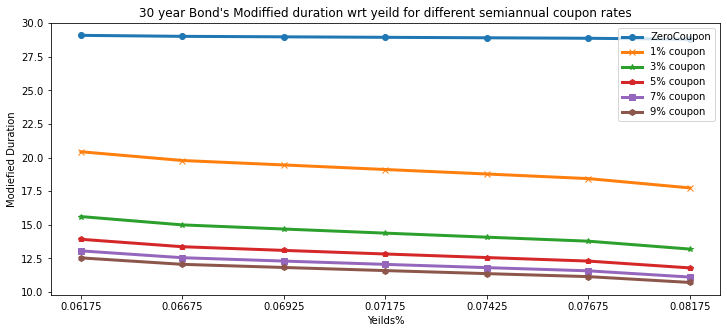

In [83]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(dur_df.columns.to_numpy(),dur_df.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
ax.plot(dur_df.columns.to_numpy(),dur_df.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
ax.plot(dur_df.columns.to_numpy(),dur_df.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
ax.plot(dur_df.columns.to_numpy(),dur_df.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
ax.plot(dur_df.columns.to_numpy(),dur_df.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
ax.plot(dur_df.columns.to_numpy(),dur_df.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")
ax.set_title("30 year Bond's Modiffied duration wrt yeild for different semiannual coupon rates")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Modiefied Duration")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()

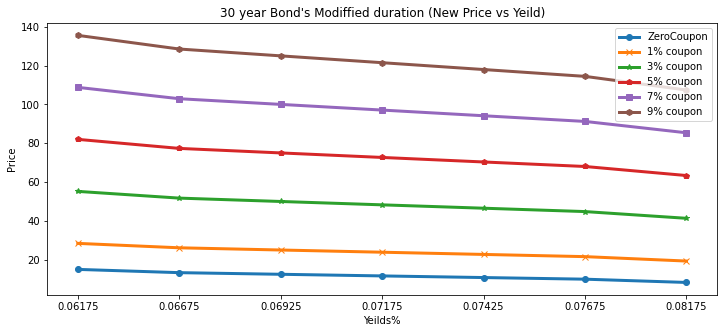

In [142]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(modprice_df.columns.to_numpy(),modprice_df.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
ax.plot(modprice_df.columns.to_numpy(),modprice_df.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
ax.plot(modprice_df.columns.to_numpy(),modprice_df.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
ax.plot(modprice_df.columns.to_numpy(),modprice_df.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
ax.plot(modprice_df.columns.to_numpy(),modprice_df.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
ax.plot(modprice_df.columns.to_numpy(),modprice_df.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")
ax.set_title("30 year Bond's Modiffied duration (New Price vs Yeild)")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Price")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()

# Bond Convexity 

In [242]:
n= 3
freq = 0.5
coupon = 10

yeild = 12
fv =100
def convexity(n,freq,coupon,yeild,fv):
    period = 0
    p_total = 0
    cf_t = 0
    for i in range(int(n/freq)):
        period = period + freq
        pv = np.exp((-1)*(yeild)*period)
        if period != n:
            cf_pv = (coupon/100)*fv*freq*pv
            cf_t = cf_t + cf_pv*np.square(period)
            p_total = p_total + cf_pv

        elif period == n :
            final_cf_pv = (fv + (coupon/100)*fv*freq)*pv
            cf_t = cf_t + final_cf_pv*np.square(period)
            p_total = p_total + final_cf_pv
    convexity = round(cf_t/p_total,3)
    return convexity,round(p_total,3)


In [235]:
convexity(3,0.5,10,0.12,100),convexity(30,0.5,0,0.07175,100)

((7.57, 94.213020554763), (900.0, 11.61933110889016))

Trying to find second derivative from given values of price and yeild

In [231]:
from scipy.interpolate import CubicSpline

x_points = np.arange(0.06175,0.09,0.005)

funct = CubicSpline(x,df_price.iloc[0])
funct(x_points),funct(x_points,1),funct(x_points,2),x_points,df_price.iloc[0]
funct(x_points,2)[3]/11.619 #doesn't match

772.4332524988544

In [244]:
n = 30
freq =0.25
fv =100
convexity_df = pd.DataFrame()
convexity_price = pd.DataFrame()
for k in data.index:
    c_dur = []
    c_price = []
    for i in x:
        #print(k,i)
        c_dur.append(convexity(n,freq,k,i,fv)[0])
        #c_price.append(convexity(n,freq,k,i,fv)[1])
    convexity_df = pd.concat([convexity_df,pd.Series(c_dur)],axis =1)
    #convexity_price = pd.concat([convexity_price,pd.Series(c_price)],axis =1)

convexity_df = convexity_df.T
#convexity_price = convexity_price.T

convexity_df.columns = data.columns
#convexity_price.columns = data.columns

convexity_df = convexity_df.set_index(data.index)
#convexity_price = convexity_price.set_index(data.index)

convexity_df #Convexity

,yeild_6.175,yeild_6.675,yeild_6.925,yeild_7.175,yeild_7.425,yeild_7.675,yeild_8.175
Coupon Rate,,,,,,,
0,900.000,900.000,900.000,900.000,900.000,900.000,900.000
1,565.838,544.340,533.371,522.272,511.059,499.745,476.880
3,379.758,359.861,350.040,340.319,330.708,321.217,302.635
5,314.556,297.342,288.928,280.650,272.515,264.529,249.019
7,281.326,265.887,258.371,250.996,243.767,236.685,222.976
9,261.181,246.950,240.037,233.262,226.627,220.136,207.587


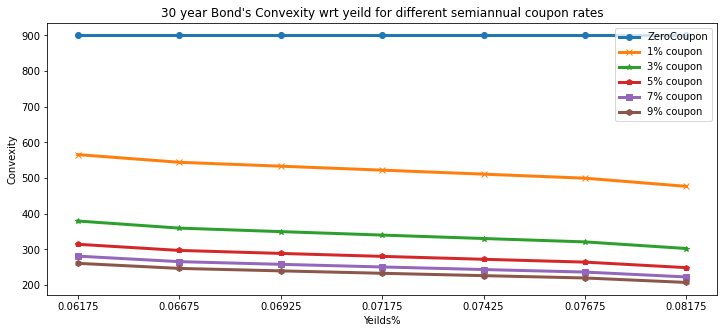

In [246]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(convexity_df.columns.to_numpy(),convexity_df.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
ax.plot(convexity_df.columns.to_numpy(),convexity_df.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
ax.plot(convexity_df.columns.to_numpy(),convexity_df.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
ax.plot(convexity_df.columns.to_numpy(),convexity_df.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
ax.plot(convexity_df.columns.to_numpy(),convexity_df.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
ax.plot(convexity_df.columns.to_numpy(),convexity_df.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")
ax.set_title("30 year Bond's Convexity wrt yeild for different semiannual coupon rates")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Convexity")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()

In [316]:
comb_price_df = pd.DataFrame()
comb_price_diff_df = pd.DataFrame()
convx_price_df = pd.DataFrame()
for e,i in enumerate(df.index):
    comb_price = []
    comb_price_diff = []
    convx_price = []
    for t, ind in enumerate(x):
        y_diff = round(x[t]-x[3],4)
        comb_price_change = round(df_price['yeild_7.175'][i]*((-1)*df['yeild_7.175'][i]*y_diff + 0.5*convexity_df['yeild_7.175'][i]*np.square(y_diff)),3)
        comb_price.append(round(comb_price_change+df_price['yeild_7.175'][i],3))
        #convx_price.append(round((df_price['yeild_7.175'][i]*(0.5*convexity_df['yeild_7.175'][i]*np.square(y_diff)))+df_price['yeild_7.175'][i],3))
        comb_price_diff.append(str(round(comb_price_change+df_price['yeild_7.175'][i],3))+f"({round(comb_price_change+df_price['yeild_7.175'][i]-data.iloc[e,t],3)})")
    comb_price_df = pd.concat([comb_price_df,pd.Series(comb_price)],axis =1)
    comb_price_diff_df = pd.concat([comb_price_diff_df,pd.Series(comb_price_diff)],axis = 1)
    #convx_price_df = pd.concat([convx_price_df,pd.Series(convx_price)],axis =1)
comb_price_df =comb_price_df.T
comb_price_df.columns = data.columns
comb_price_df = comb_price_df.set_index(data.index)

comb_price_diff_df =comb_price_diff_df.T
comb_price_diff_df.columns = comb_price_diff_df.columns
comb_price_diff_df = comb_price_diff_df.set_index(data.index)

#convx_price_df =convx_price_df.T
#convx_price_df.columns = data.columns
#convx_price_df = convx_price_df.set_index(data.index)

print(comb_price_df,comb_price_diff_df)

             yeild_6.175  yeild_6.675  yeild_6.925  yeild_7.175  yeild_7.425  yeild_7.675  yeild_8.175
Coupon Rate                                                                                           
0                 15.628       13.493       12.523       11.619       10.780       10.007        8.656
1                 29.176       26.348       25.051       23.832       22.691       21.627       19.733
3                 56.254       52.043       50.091       48.242       46.496       44.852       41.872
5                 83.347       77.751       75.144       72.664       70.312       68.087       64.020
7                110.427      103.446      100.184       97.075       94.118       91.313       86.160
9                137.507      129.143      125.226      121.487      117.925      114.540      108.301                            0                1                2                3                4               5                6
Coupon Rate                                   

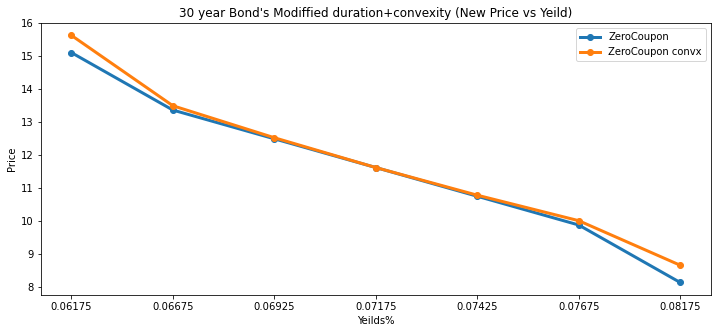

In [314]:
fig, ax =plt.subplots(figsize = (12,5))
ax.plot(df_TD.columns.to_numpy(),df_TD.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon")
#ax.plot(comb_price_df.columns.to_numpy(),comb_price_df.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon")
#ax.plot(comb_price_df.columns.to_numpy(),comb_price_df.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon")
#ax.plot(comb_price_df.columns.to_numpy(),comb_price_df.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon")
#ax.plot(comb_price_df.columns.to_numpy(),comb_price_df.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon")
#ax.plot(comb_price_df.columns.to_numpy(),comb_price_df.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon")

ax.plot(comb_price_df.columns.to_numpy(),comb_price_df.iloc[0].to_numpy(), linewidth=3,marker = 'o', label = "ZeroCoupon convx")
#ax.plot(convx_price_df.columns.to_numpy(),convx_price_df.iloc[1].to_numpy(), linewidth=3,marker = 'x', label = "1% coupon convx")
#ax.plot(convx_price_df.columns.to_numpy(),convx_price_df.iloc[2].to_numpy(), linewidth=3,marker = '*', label = "3% coupon convx")
#ax.plot(convx_price_df.columns.to_numpy(),convx_price_df.iloc[3].to_numpy(),linewidth=3,marker = 'p', label = "5% coupon convx")
#ax.plot(convx_price_df.columns.to_numpy(),convx_price_df.iloc[4].to_numpy(),linewidth=3,marker = 's', label = "7% coupon convx")
#ax.plot(convx_price_df.columns.to_numpy(),convx_price_df.iloc[5].to_numpy(),linewidth=3,marker = 'h', label = "9% coupon convx")

ax.set_title("30 year Bond's Modiffied duration+convexity (New Price vs Yeild)")
ax.set_xlabel("Yeilds%")
ax.set(xticks = np.arange(len(x)), xticklabels = x)
ax.set_ylabel("Price")
#ax.set_ylim([0.225,0.325])
ax.legend()
plt.show()